In [1]:
import numpy as np
import pandas as pd

from plotly.subplots import make_subplots

from pychemelt import Monomer
from pychemelt.utils.plotting import *

import plotly.graph_objs as go

import sys
sys.path.append('../')
from scripts import display_figure_static, set_condition_indexes_to_false

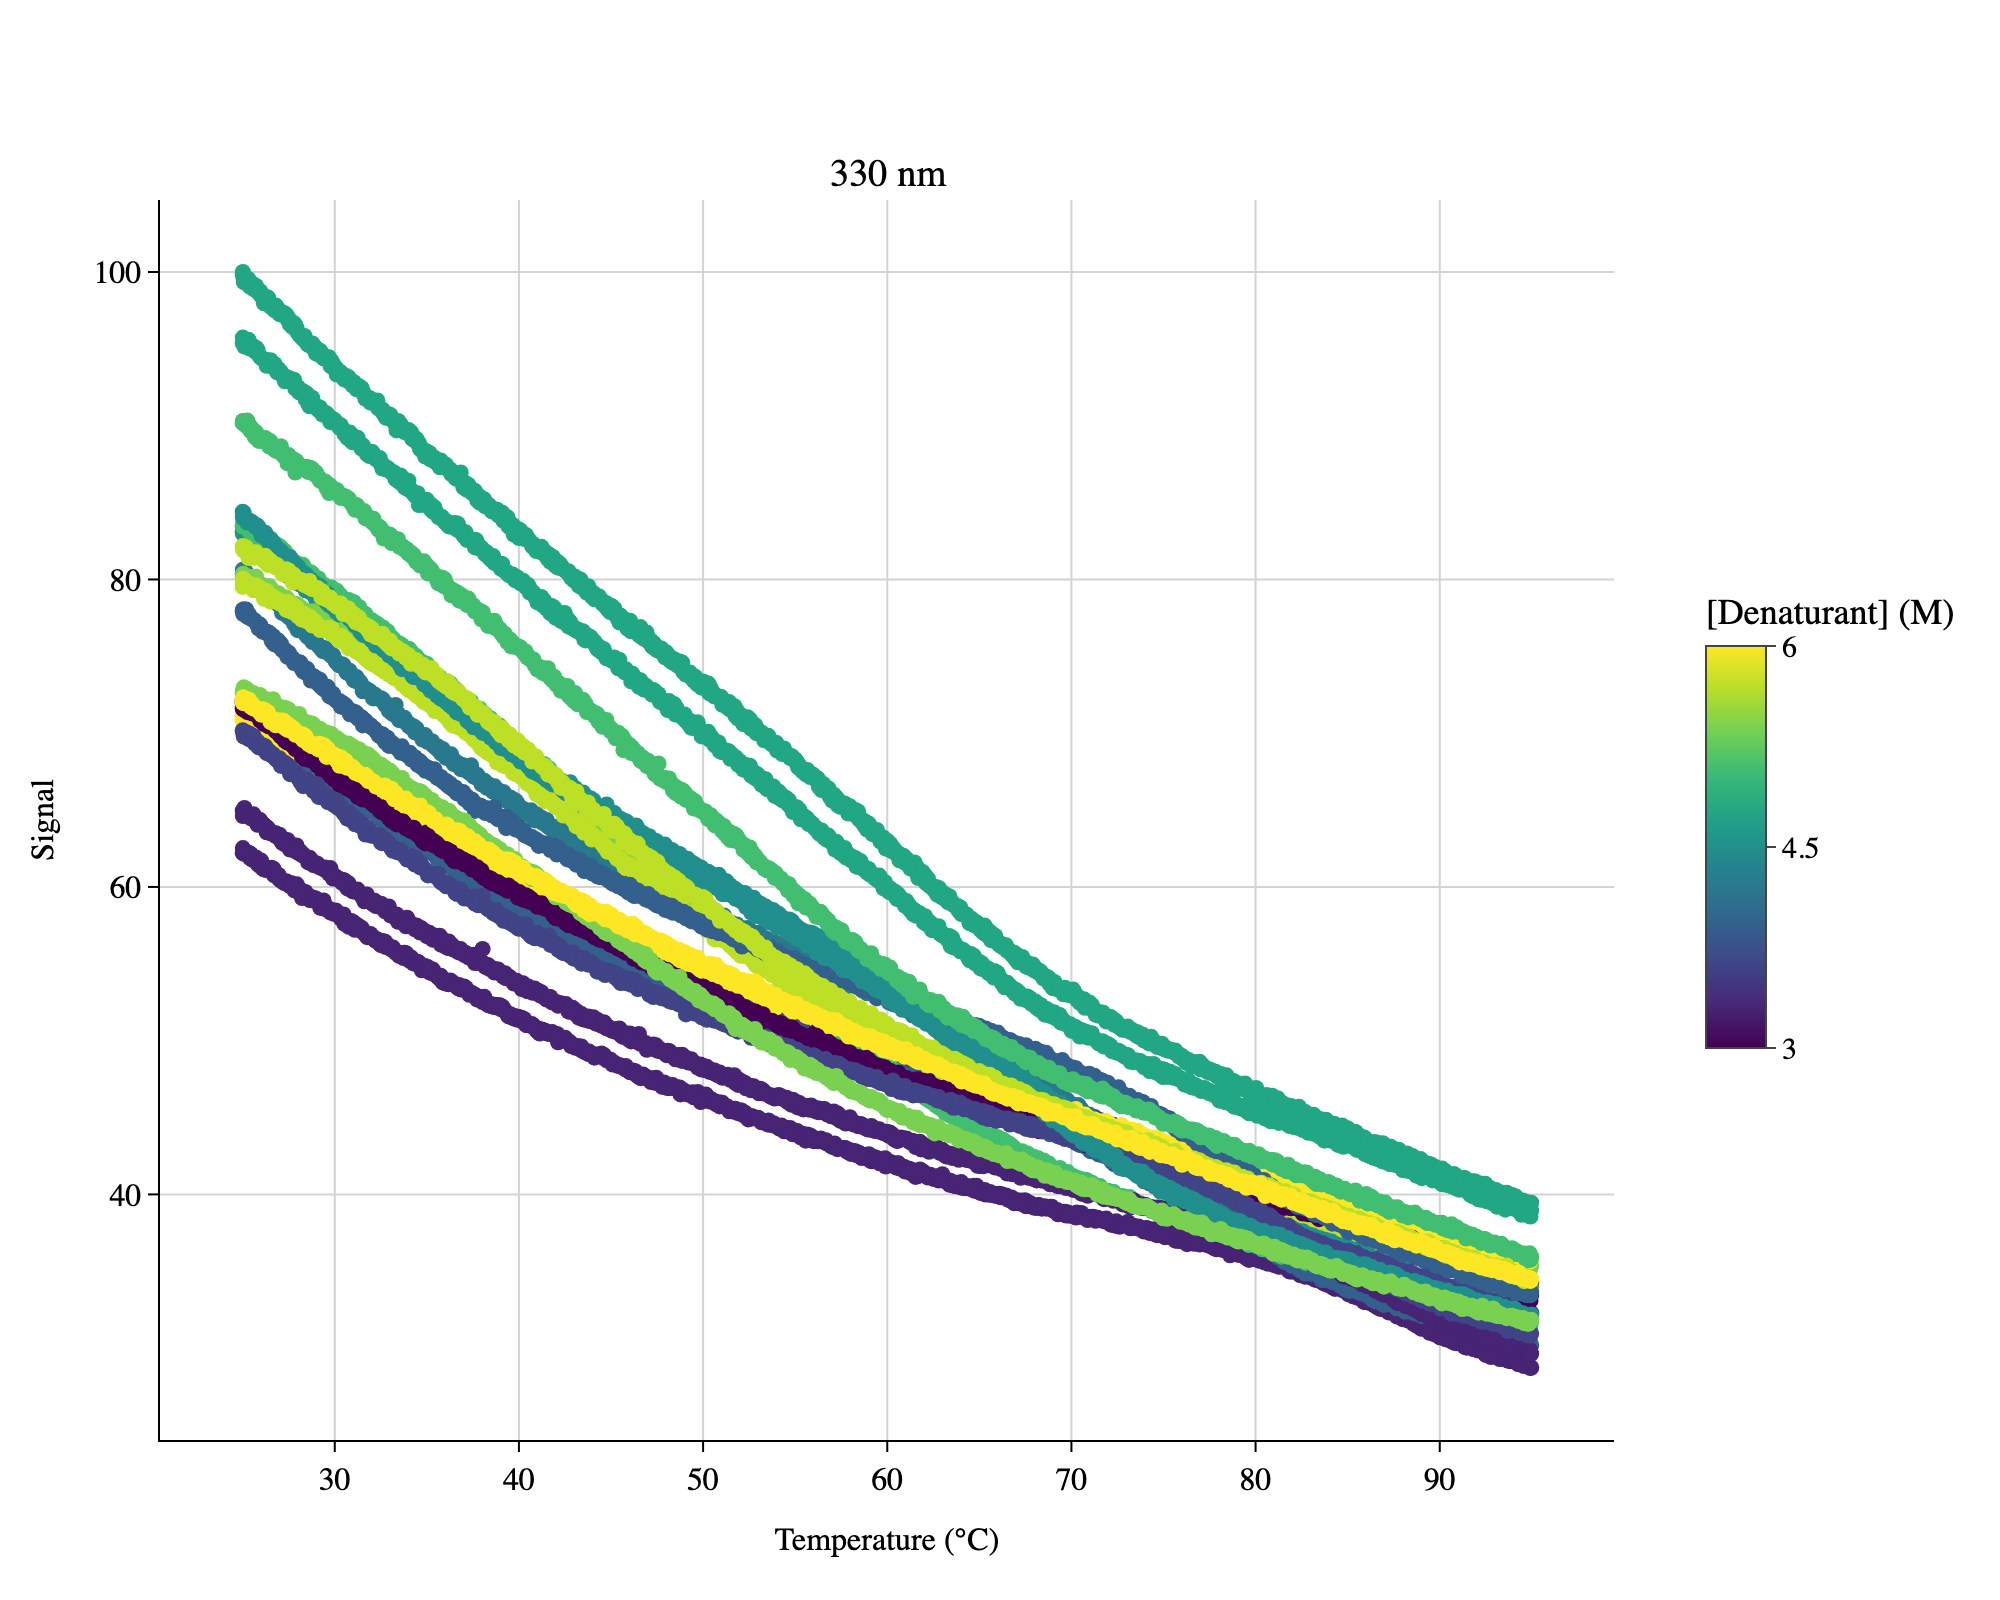

In [2]:
INDEX = 8
NAME = "A4B" # Name used in the manuscript

# creating a Sample object for the storage and processing of the DSF data
sample = Monomer()

# reading the data
sample.read_file(f'../../data/retiter2_A4B_P3A.xlsx')

sample.set_denaturant_concentrations()

# Selecting conditions
sample.set_signal(['330 nm'])#, '350 nm'])

conditions = [True]*48
# Index of the curves to be excluded from the analysis, starting from 1
outliers_or_other_data = ["23-44","16"] 

conditions = set_condition_indexes_to_false(conditions,outliers_or_other_data)

#using all curves except the curve without denaturant as in the paper
sample.select_conditions(conditions,normalise_to_global_max=True)

#Plotting the selected signals against the temperature
fig = plot_unfolding(sample)
display_figure_static(fig,height=800, width=1000)

In [3]:
# Reducing the amount of data and preprocessing steps for a faster analysis
sample.pre_fit = False
sample.max_points = 200

sample.expand_multiple_signal()

sample.estimate_baseline_parameters(
    native_baseline_type='linear',
    unfolded_baseline_type='exponential',
)

# estimations of parameters
sample.estimate_derivative()
sample.guess_Tm()

# All local fit for parameter estimation
sample.fit_thermal_unfolding_local()

# Setting the number of residues of the protein for an initial estiamte of the Cp value
# We use a lower value than expected because of the hyperstability.
sample.n_residues = 60 
sample.guess_Cp()

sample.set_signal_id()

sample.compare_models(
    native_baseline_types=['linear','quadratic','exponential'],
    unfolded_baseline_types=['linear','quadratic','exponential'],
    global_model_types=['global_global_global'],
    neff=None
)

# Replace sample with the best model
best_model = sample.fit_objects[0]

In [4]:
print(sample.comparison_df)
# add sample name to the comparison dataframe - first column
sample.comparison_df.insert(0, 'Sample', NAME)
# Export to csv - use sample name as filename
sample.comparison_df.to_csv(f'./comparison_tables/{INDEX}_{NAME}_comparison.csv', index=False)

#sample.params_df[:4]

  Native Baseline Unfolded Baseline                           Model Type  \
0       quadratic            linear  Global slopes and global intercepts   
1       quadratic       exponential  Global slopes and global intercepts   
2     exponential            linear  Global slopes and global intercepts   
3     exponential       exponential  Global slopes and global intercepts   
4       quadratic         quadratic  Global slopes and global intercepts   
5     exponential         quadratic  Global slopes and global intercepts   
6          linear            linear  Global slopes and global intercepts   
7          linear       exponential  Global slopes and global intercepts   
8          linear         quadratic  Global slopes and global intercepts   

      Tm   ΔHm   ΔCp  m-value      AIC      BIC     EBIC  Reduced χ²  
0  115.0  92.6  0.94     1.93 -1786.02 -1604.46 -1273.89      0.4949  
1  115.2  93.0  0.94     1.94 -1779.98 -1592.56 -1253.24      0.4959  
2  115.2  73.5  0.69     1

In [5]:
# Estimate error using leave_one_out cross validation
best_model.leave_one_out_cross_validation()

# Save the leave one out results to a csv file
best_model.loo_df.to_csv(f'./leave_one_out_results/{INDEX}_{NAME}_loo.csv', index=False)

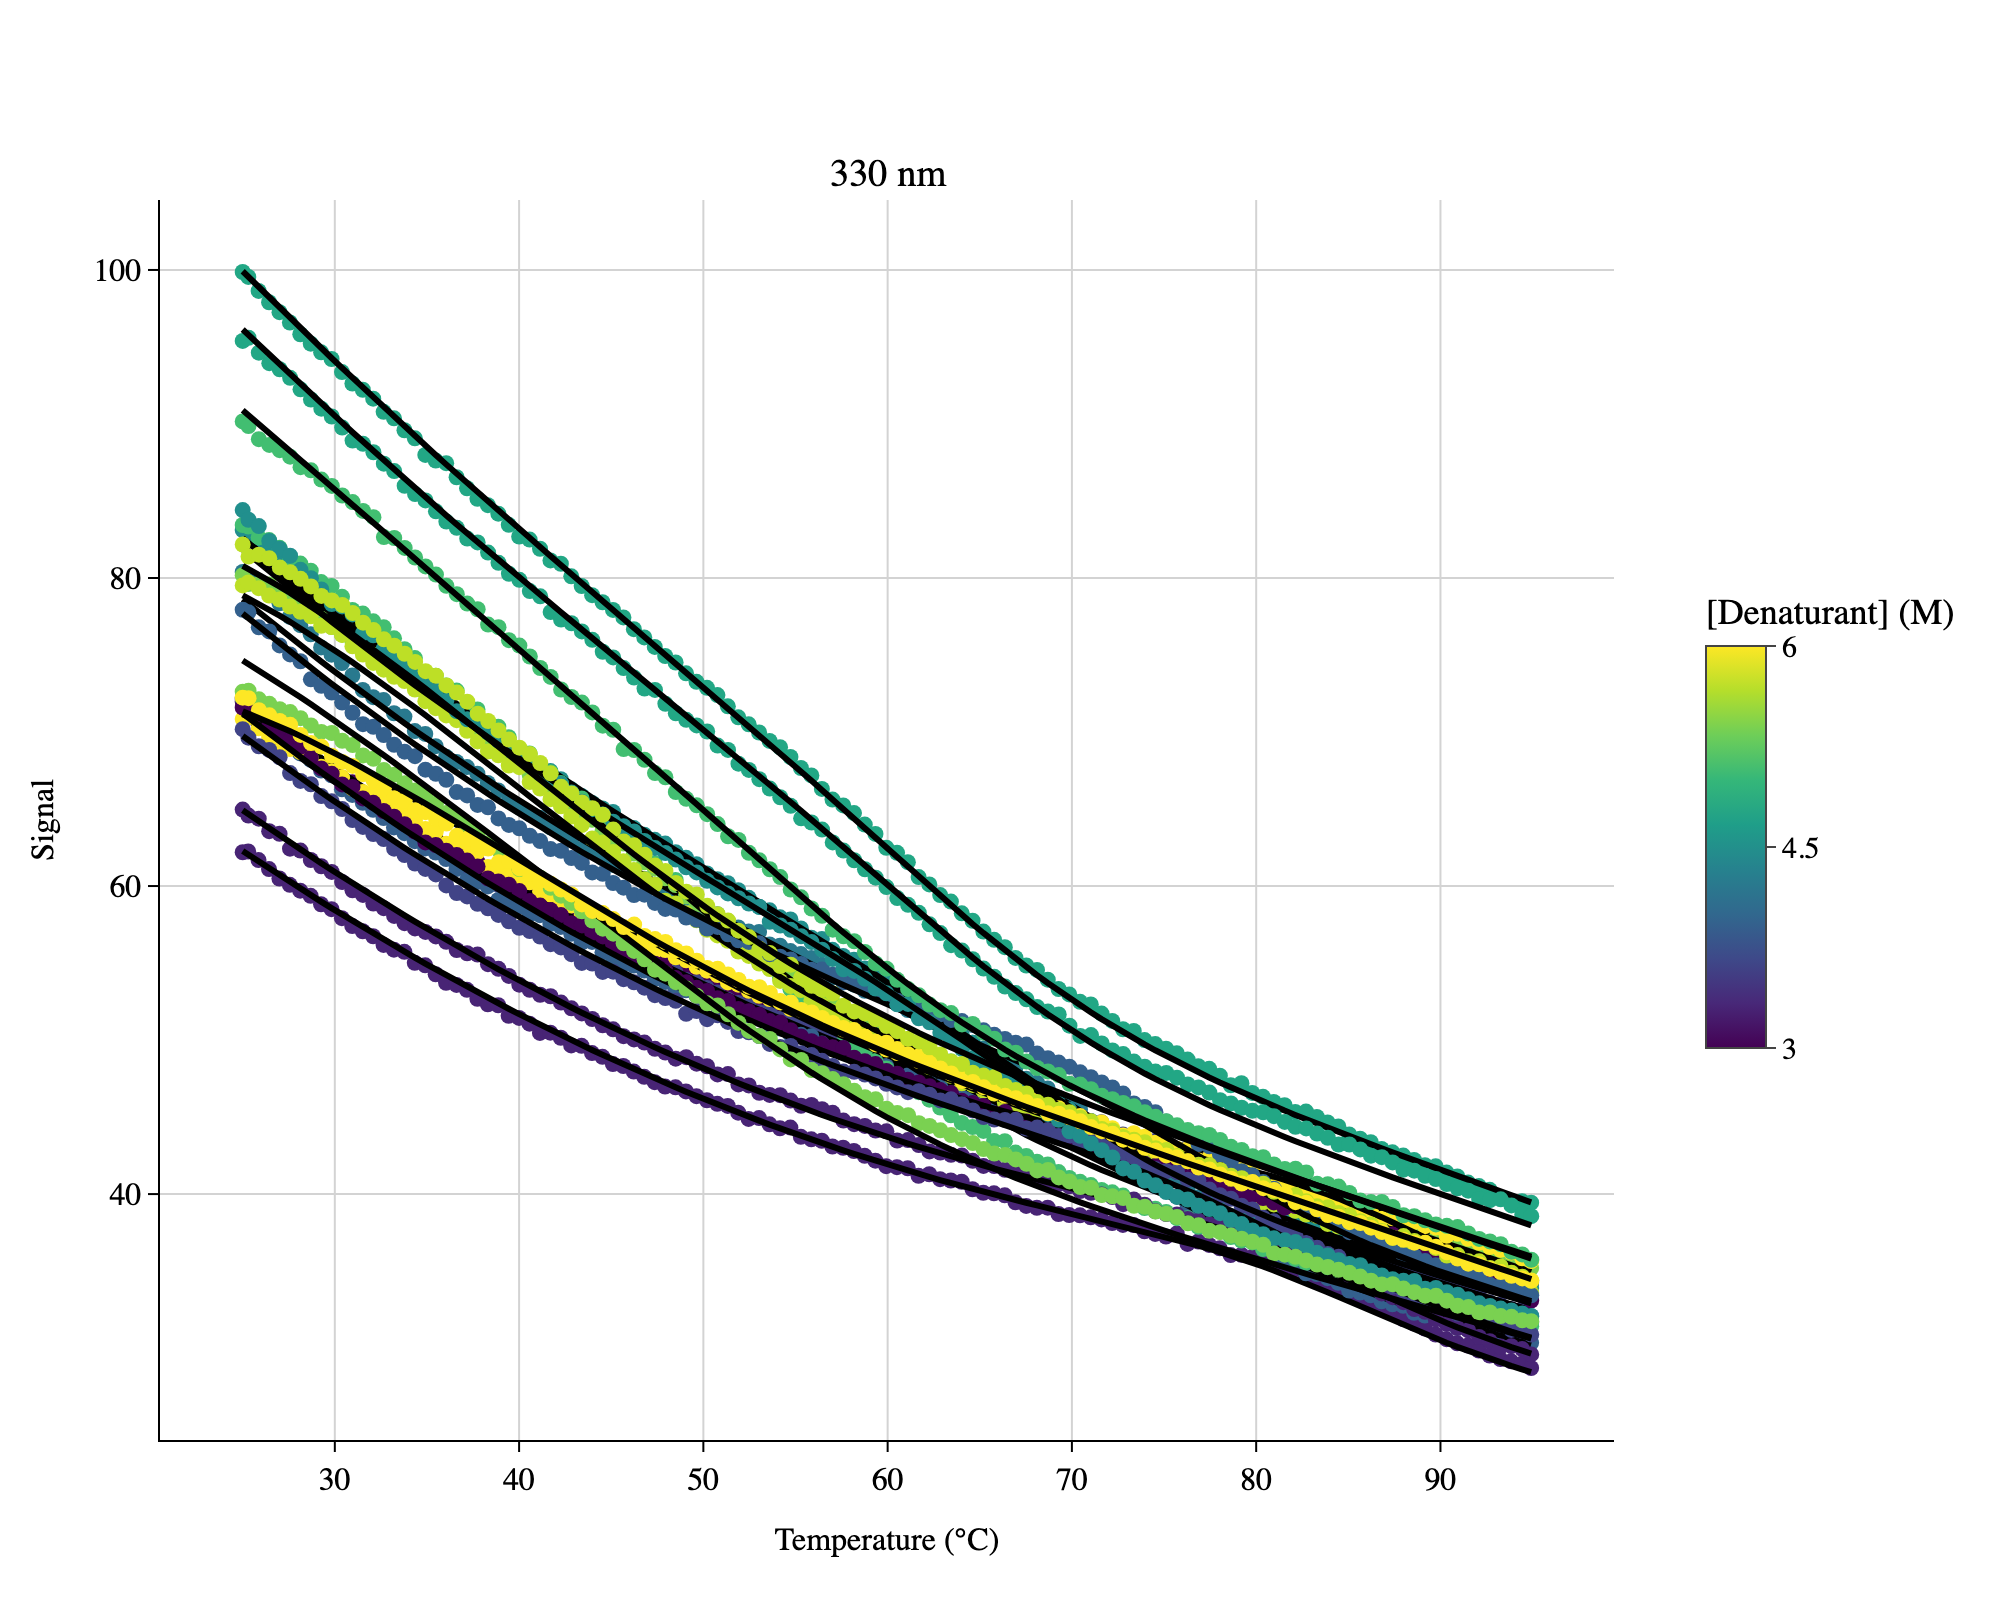

In [6]:
fig = plot_unfolding(best_model)
display_figure_static(fig,height=800, width=1000)

here


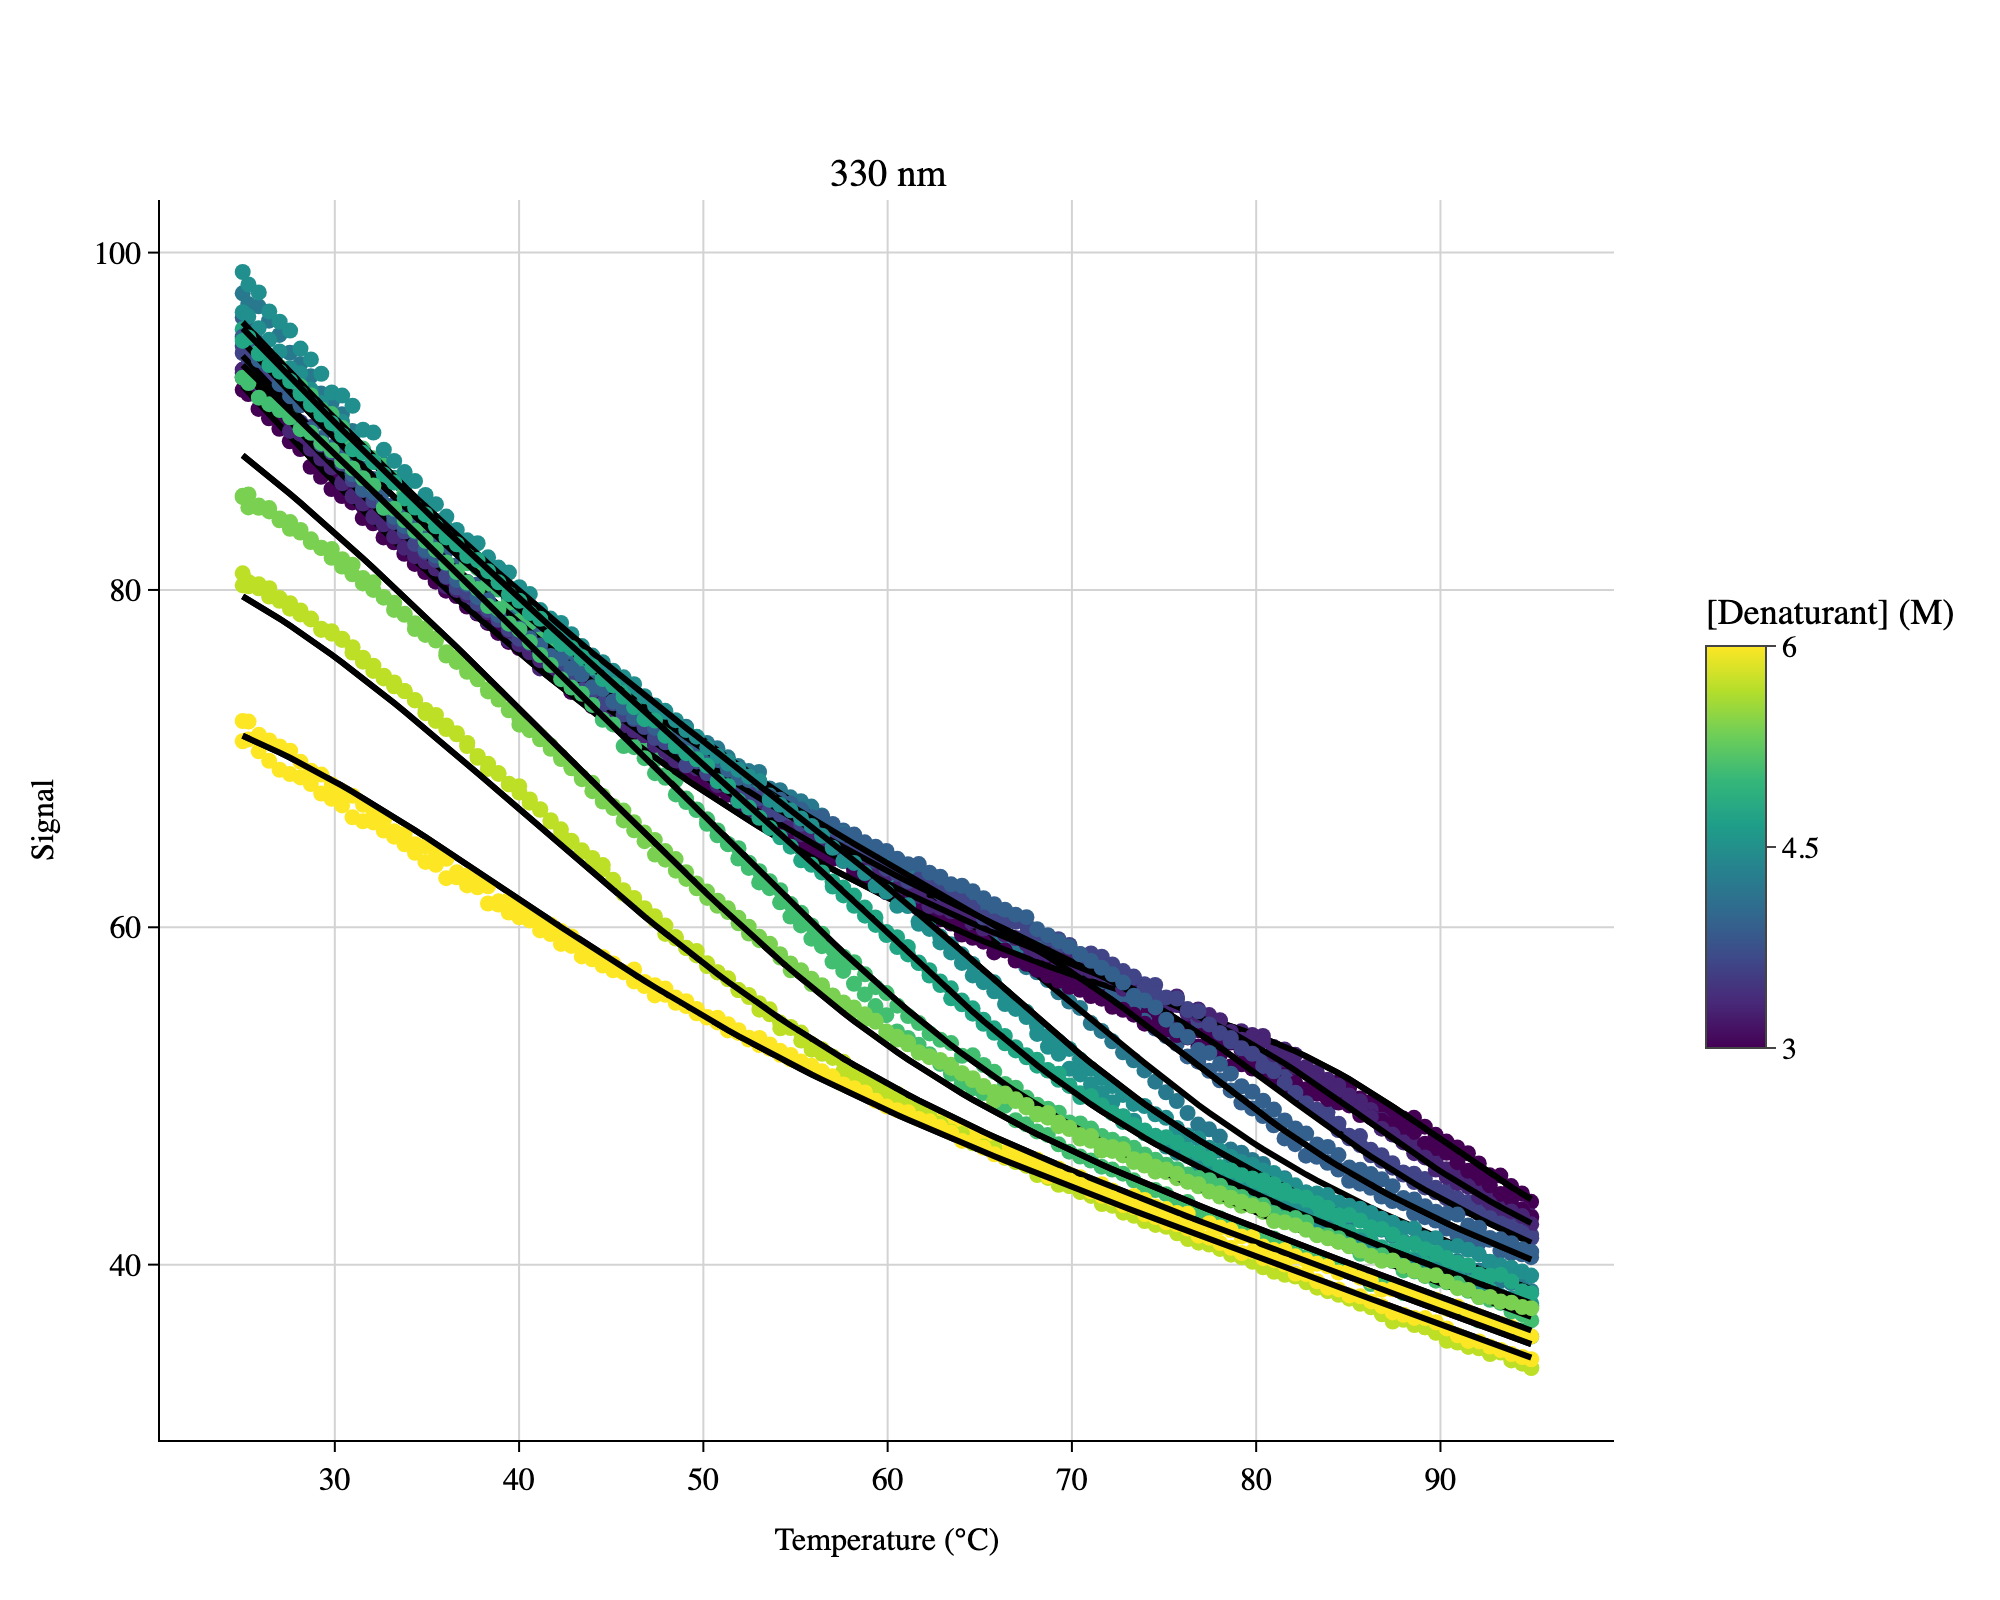

In [7]:
# Plot the curves taking into account the effect of the scaling factor
fig = plot_unfolding(best_model,use_scaled_data=True)
# save figure
fig.write_image(f"./figures/{INDEX}_{NAME}_unfolding_curves_fitted_scaled.png")

display_figure_static(fig,height=800, width=1000)